# GP coherence field in embedding space, at fitted parameters

Loads a fitted theta posterior from `results/<RESULTS_NAME>/` and plots, per condition, the
model's coherence field `P(kind-linked)` over the 2-D feature embedding: the GP is conditioned on
that condition's training generic utterances only (ratings-free Laplace mode via
`inference.gp_coherence_field`), at the posterior-median `(length_scale, mu_0, sigma)` shared
across conditions. Test points are overlaid colored by their empirical mean rating on the same
color scale, so field-vs-data agreement is visible directly.

Set `RESULTS_NAME` to any results subdirectory that contains a `posterior.npz` /
`posterior-fitted-shapes.npz` written by `run_vbmc` / `run_vbmc_free_shapes` (the fitted-shapes
posterior is preferred when both exist).

In [25]:
RESULTS_NAME = 'study9-vbmc-laplace-beta'   # results subdirectory under ./results
DATA_CSV     = '../../data/study9_prereg.csv'  # ratings used to color the test points

import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")
import sys
sys.path.insert(0, ".")

import json
import numpy as np
import matplotlib.pyplot as plt

import inference as inf

RESULTS_DIR = os.path.join('results', RESULTS_NAME)
post_path = os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz')
if not os.path.exists(post_path):
    post_path = os.path.join(RESULTS_DIR, 'posterior.npz')
z = np.load(post_path, allow_pickle=True)
meta = json.loads(str(z['meta']))
LS, MU0, SIGMA = (float(np.median(z['ls_samples'])), float(np.median(z['mu0_samples'])),
                  float(np.median(z['sigma_samples'])))
print(f"loaded {post_path}  (convergence: {meta['convergence_status']})")
print(f"posterior-median theta: ls={LS:.3f}  mu_0={MU0:+.3f}  sigma={SIGMA:.3f}")

geom = inf.load_geometry()
J = geom['J']
responses_cond, _ = inf.load_responses(DATA_CSV)
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in inf.CONDITIONS}
N_cond   = {c: int(responses_cond[c].shape[0]) for c in inf.CONDITIONS}

loaded results/study9-vbmc-laplace-beta/posterior-fitted-shapes.npz  (convergence: probable)
posterior-median theta: ls=0.205  mu_0=-0.397  sigma=0.782


## Coherence field per condition

Contours: GP-conditional `P(kind-linked)` given the condition's trained region. Dark points:
trained features (all heard as generics). Outlined points: test features, colored by empirical
mean rating on the panel's color scale. Panel titles report the correlation between the field
evaluated at the test locations and the mean ratings.

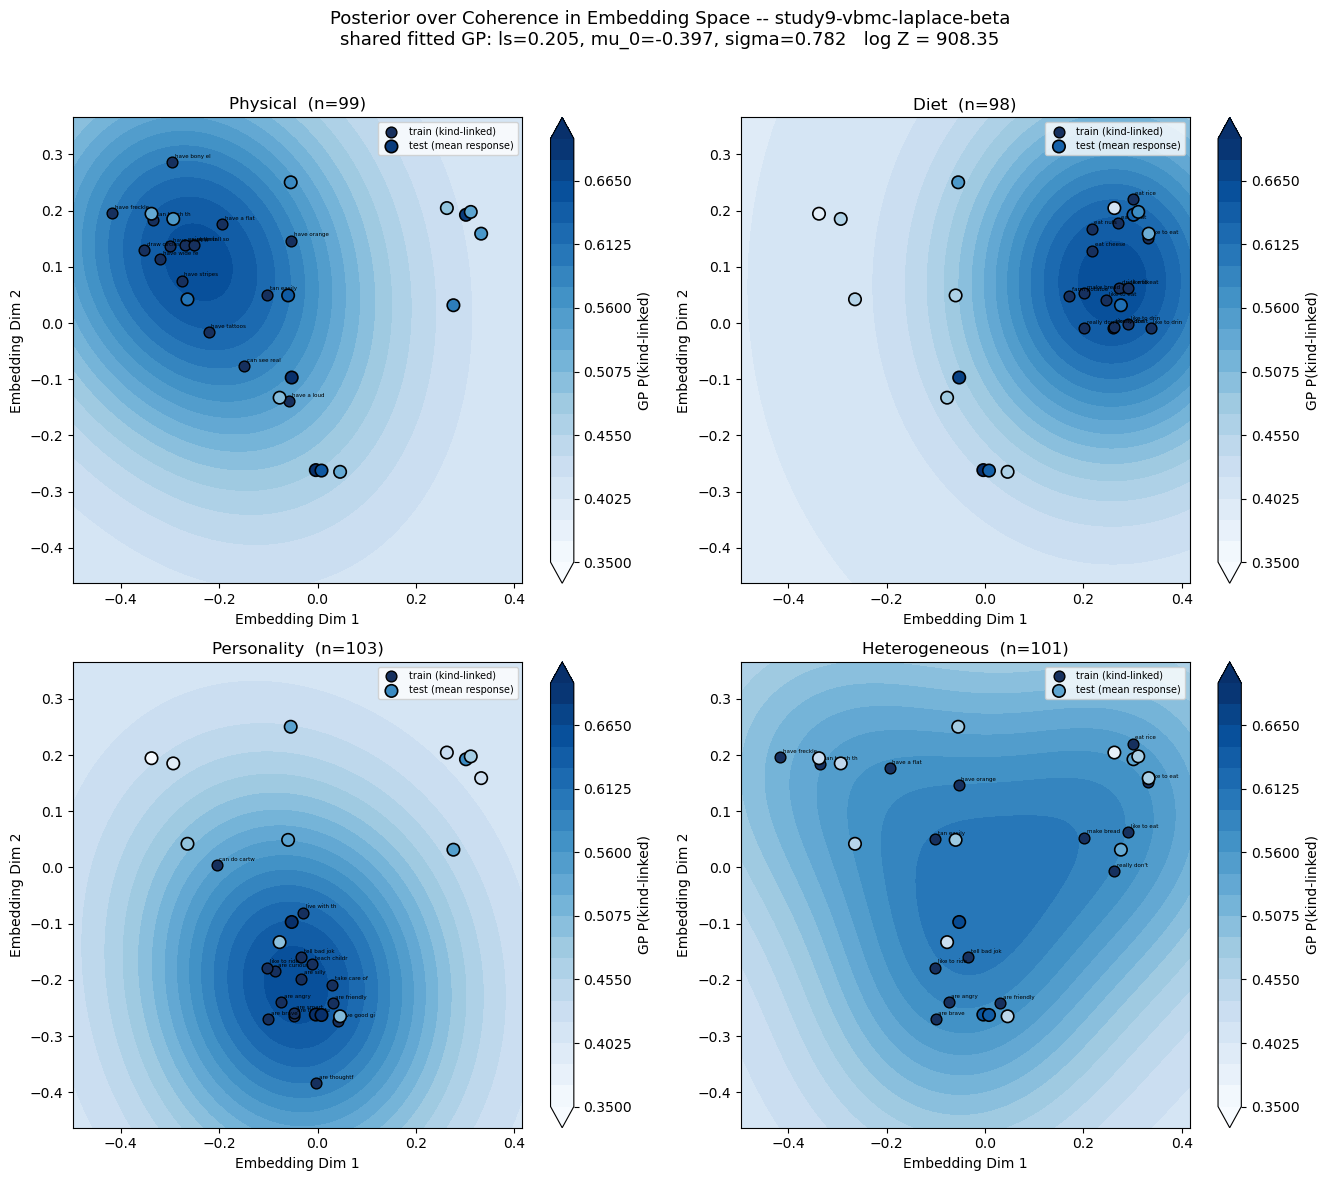

In [26]:
all_x = np.vstack([np.array(geom['x_test'])] + [np.array(geom['x_train_cond'][c]) for c in inf.CONDITIONS])
pad = 0.08
(x_lo, y_lo), (x_hi, y_hi) = all_x.min(0) - pad, all_x.max(0) + pad
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 80), np.linspace(y_lo, y_hi, 80))
X_grid = np.column_stack([gx.ravel(), gy.ravel()])
x_test_np = np.array(geom['x_test'])

# fixed 0..1 color scale shared across all panels (and across null / non-null runs),
# so a uniformly high null field reads as uniformly dark blue rather than auto-rescaled.
levels = np.linspace(0.35, 0.7, 21)
norm   = plt.Normalize(vmin=0.35, vmax=.7)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 12))
for ax, c in zip(axes.ravel(), inf.CONDITIONS):
    field    = inf.gp_coherence_field(geom, c, LS, MU0, SIGMA, X_grid).reshape(gx.shape)
    pz1_test = inf.gp_coherence_field(geom, c, LS, MU0, SIGMA, x_test_np)
    cs = ax.contourf(gx, gy, field, levels=levels, cmap='Blues', norm=norm, extend='both')
    cb = fig.colorbar(cs, ax=ax); cb.set_label('GP P(kind-linked)')

    x_tr = np.array(geom['x_train_cond'][c])
    ax.scatter(x_tr[:, 0], x_tr[:, 1], s=60, color='#16305e', edgecolor='k',
               zorder=3, label='train (kind-linked)')
    for (xx, yy), nm in zip(x_tr, geom['train_names_cond'][c]):
        ax.annotate(nm[:12], (xx, yy), fontsize=4, xytext=(2, 3), textcoords='offset points')
    ax.scatter(x_test_np[:, 0], x_test_np[:, 1], s=80, c=emp_cond[c], cmap='Blues', norm=norm,
               edgecolor='k', linewidth=1.2, zorder=3, label='test (mean response)')

    r = np.corrcoef(pz1_test, emp_cond[c])[0, 1]
    ax.set_title(f"{c.capitalize()}  (n={N_cond[c]})") # \nr(field @ test, mean rating) = {r:+.2f}
    ax.set_xlabel('Embedding Dim 1'); ax.set_ylabel('Embedding Dim 2')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle(f"Posterior over Coherence in Embedding Space -- {RESULTS_NAME}\n"
             f"shared fitted GP: ls={LS:.3f}, mu_0={MU0:+.3f}, sigma={SIGMA:.3f}"
             f"   log Z = {meta['elbo']:.2f}", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.965])
# out_png = os.path.join(RESULTS_DIR, 'gp-coherence-field.png')
# fig.savefig(out_png, dpi=150, bbox_inches='tight')
# print('saved', out_png)
plt.show()